In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
import os

print(os.getcwd())

c:\Users\ARCHITA\Desktop\fintech\Mutual_Fund_Analytics\notebooks


In [6]:
import plotly.express as px

nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

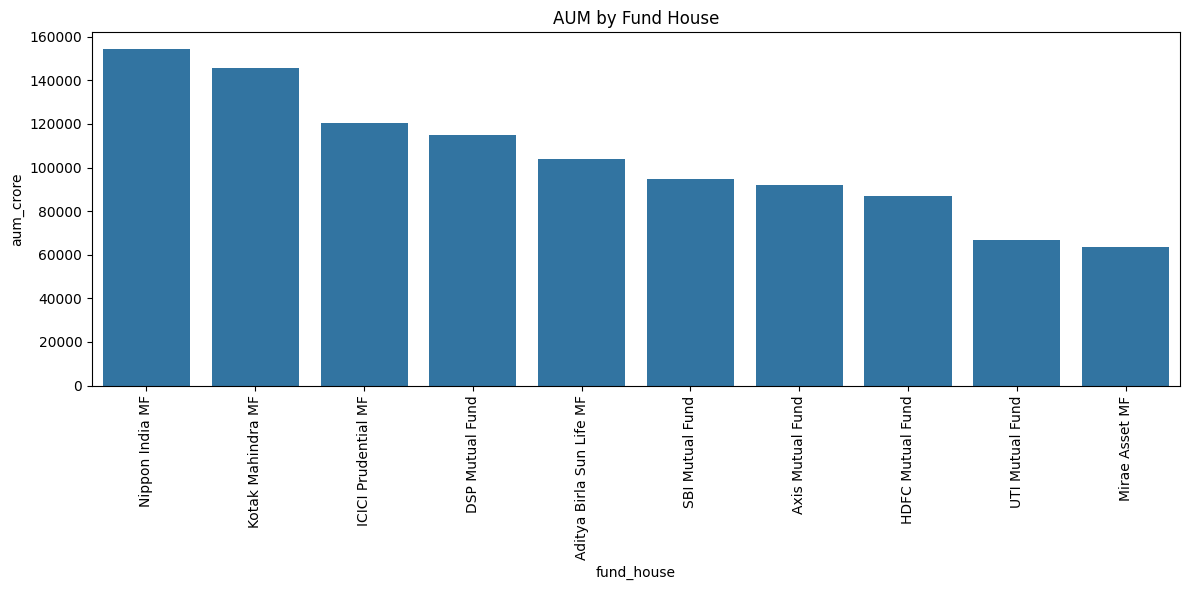

In [7]:
perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

top_aum = perf.groupby("fund_house")["aum_crore"].sum().reset_index()

top_aum = top_aum.sort_values(
    "aum_crore",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")

plt.tight_layout()

plt.show()

In [8]:
txn = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

monthly = txn.groupby(
    txn["transaction_date"].dt.to_period("M")
)["amount_inr"].sum()

monthly = monthly.reset_index()

monthly["transaction_date"] = monthly[
    "transaction_date"
].astype(str)

fig = px.line(
    monthly,
    x="transaction_date",
    y="amount_inr",
    title="Monthly SIP Inflow Trend"
)

fig.show()

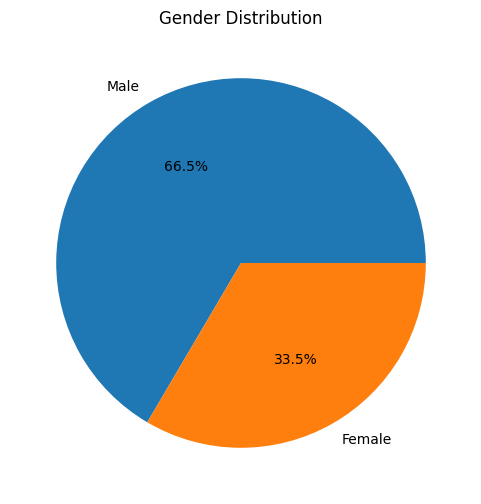

In [9]:
gender = txn["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

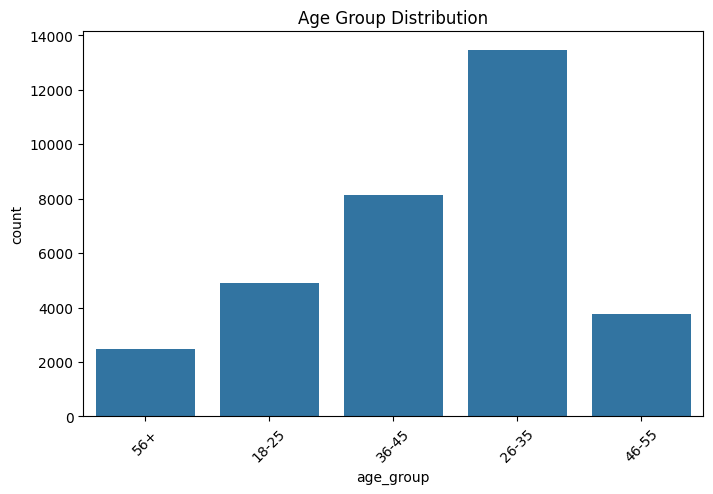

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=txn,
    x="age_group"
)

plt.title("Age Group Distribution")

plt.xticks(rotation=45)

plt.show()

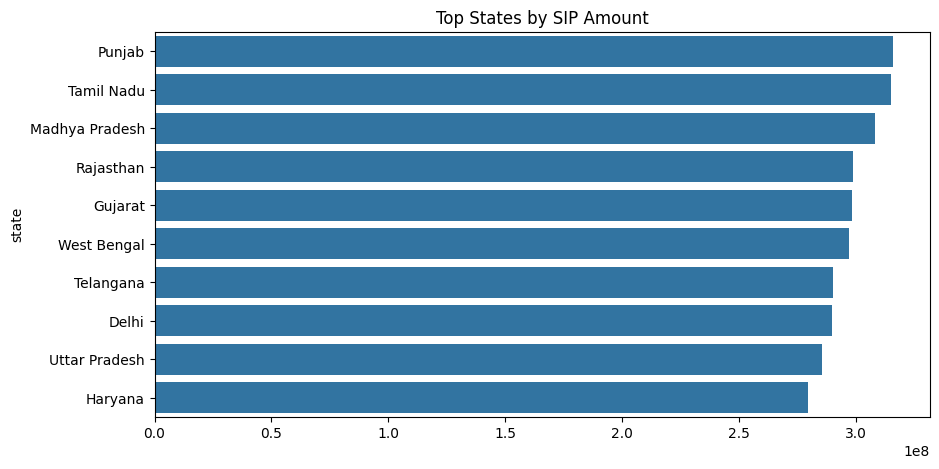

In [11]:
state_data = txn.groupby("state")["amount_inr"].sum()

state_data = state_data.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Top States by SIP Amount")

plt.show()

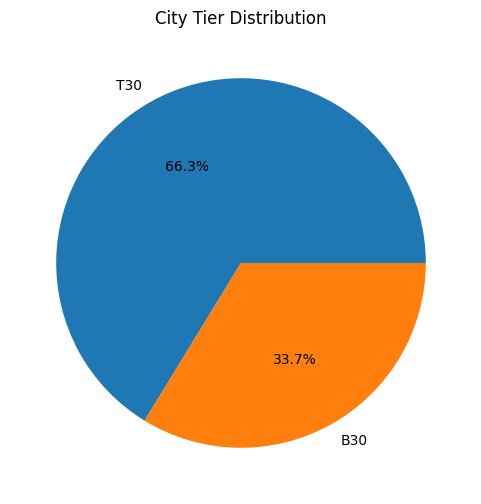

In [12]:
tier = txn["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier.values,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("City Tier Distribution")

plt.show()

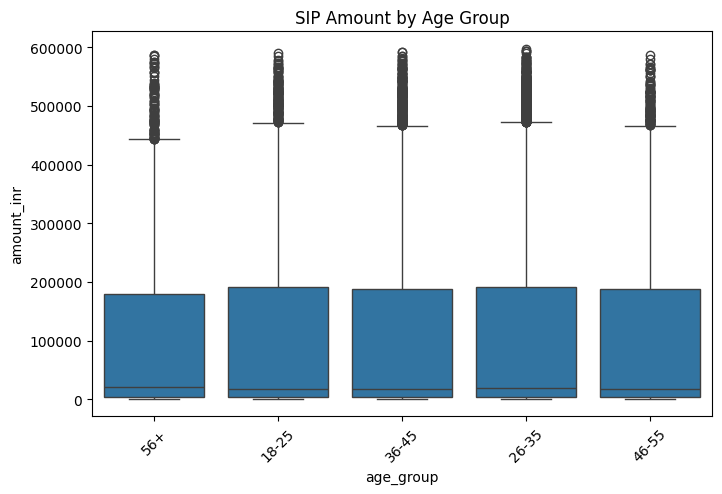

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.xticks(rotation=45)

plt.show()

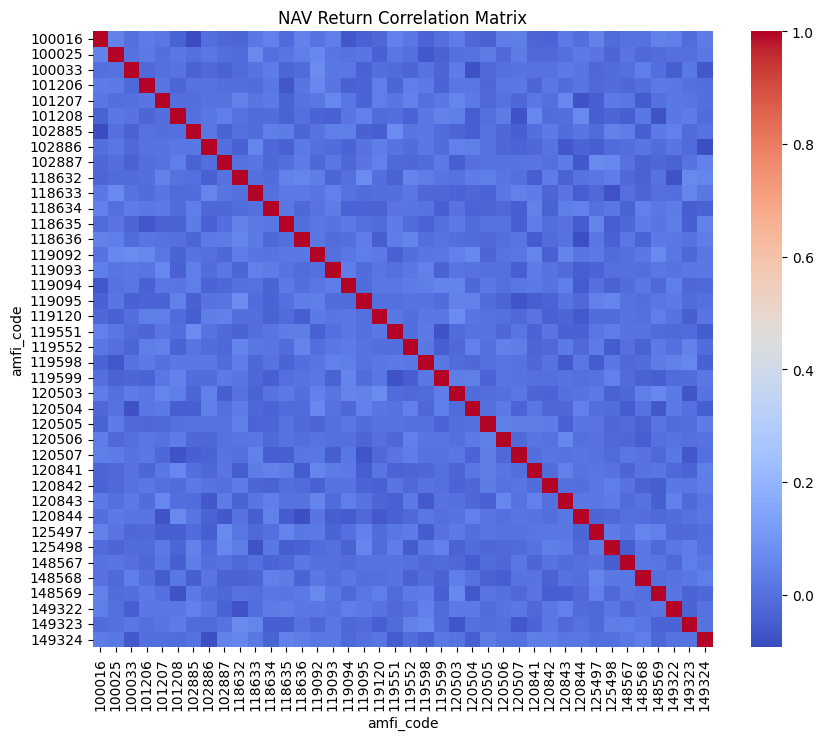

In [14]:
returns = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = returns.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

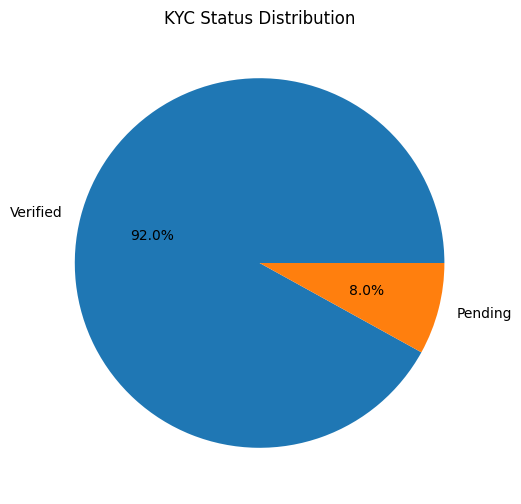

In [15]:
kyc = txn["kyc_status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    kyc.values,
    labels=kyc.index,
    autopct="%1.1f%%"
)

plt.title("KYC Status Distribution")

plt.show()

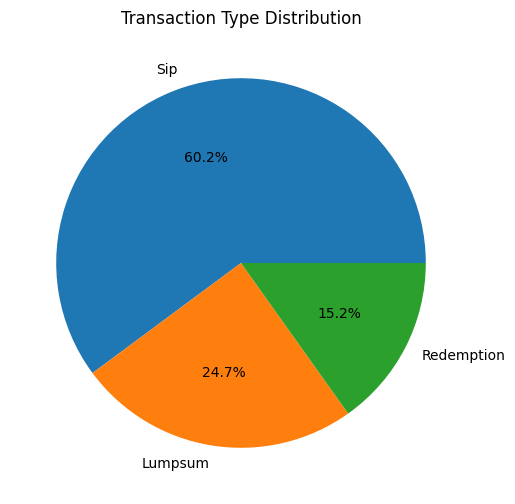

In [16]:
txn_type = txn["transaction_type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    txn_type.values,
    labels=txn_type.index,
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")

plt.show()